<a href="https://colab.research.google.com/github/VincentUwumboriyhieGmayinaam/AI-Enabled-Depression-Screening-and-Decision-Support-for-PLHIV-in-Ghana-Using-PHQ-9/blob/main/AI_in_Healthcare_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
# ============================
# Multi-model Depression Risk Training (PLHIV)
# ============================
# - One-Hot Encoding for categoricals
# - Scaling for numeric features
# - Outcome: PHQ-9 >= 10 -> 1 else 0 (risk-score target is probability of class 1)
# - Models: Logistic, DecisionTree, RandomForest, KNN, GradientBoosting,
#           BernoulliNB (with binarizer), XGBoost*, LightGBM*, CatBoost*, MLP NN
#           (*optional if installed)
# - Outputs saved in ./outputs/
# ============================

import os, json, warnings
warnings.filterwarnings("ignore")
import sys
!{sys.executable} -m pip install catboost
import numpy as np
import pandas as pd
import shap
import joblib
import seaborn as sns
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, Binarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
import joblib
import matplotlib.pyplot as plt

# Optional libraries
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except Exception:
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except Exception:
    CatBoostClassifier = None

In [74]:
# ------------------------------
# 0) Load data
# ------------------------------
DATA_PATH = "/content/drive/MyDrive/Data CSV.csv"   # <- change if needed
df = pd.read_csv(DATA_PATH)

# ------------------------------
# 1) Define variables by Section using your actual headers
# ------------------------------

# Section A: Demographics
sectionA_demo = [
    "Age", "Sex", "Ethnicity", "Religion", "Marital status",
    "Educational level", "Occupation"
]

# Section A: HIV / Clinical
sectionA_clinical = [
    "Year of Diagnosis", "Year_Diagnosis",
    "StageofHIVclassification_", "WhatisyourCD4count_",
    "HowlonghaveyoubeenonART_",
    "Haveyoueverbeenscreenedorq_", "Wereyoueveraskedtogofora_",
    "Whatwasyourresult_", "Coughfortwo2ormoreweeks_", "Nightsweats_",
    "Chillsandfever_", "Chestpain_", "Weightloss_",
    "HaveyoubeeninitiatedonTPT_", "IfYESwhendidyouinitiate_"
]

# Section B: PHQ-9 items (PHQ-2 are first two)
phq9_items = [
    "Littleinterestorpleasureind_1",
    "Feelingdowndepressedorhope_1",
    "Troublefallingorstayingaslee_1",
    "Feelingtiredorhavinglittlee_1",
    "Poorappetiteorovereating_1",
    "Feelingbadaboutyourselfor_1",
    "Troubleconcentratingonthings_1",
    "Movingorspeakingsoslowlytha_1",
    "Thoughtsthatyouwouldbebette_1",
]

# Section C: Risk-factor domains (examples from your file)
risk_health = [
    "Doyouhaveanycoexistingphys_", "Haveyouexperiencedanymedicat_",
    "DoesHIVAIDSimpactyourdaily_1", "Arethereanyspecificphysical_1",
    "Howdoyouratetheoverallimpa_1",
]
risk_behavior = [
    "Doyouengageinsubstanceabuse_", "Doyouusetobacco_",
    "Haveyoureceivedinformationan_", "Ifyeshaveyouimplementedthe_",
    "Adheretorecommendedlifestyle",
]
risk_service = [
    "Accesstohealthcareservices_1", "Qualityofhealthcareservices_1",
    "Availabilityofcounselingandp_1", "Tailoredmentalhealthservices_1",
    "Positiveproviderpatientrelati_1", "Howcomfortabledoyoufeeldisc_1",
]
risk_cultural = [
    "Doculturalbeliefsinfluenceyo_1", "Arethereculturalnormssurroun_1",
    "Doyouthinkthereisastigma_1", "Arethereculturalbeliefsorat_1",
    "Howacceptingisyourculturalc_1", "BS_1",
]
risk_psych = [
    "Doyoutendtoworryorfeelanx_1", "Haveyouexperiencedfeelingsof_1",
    "Howoftendoyoufeellowinene_1", "Doyoufinditchallengingtoex_1",
    "Haveyouhadrecurrentthoughts_1",
    "Doyoutendtoworryorfeelanx_12", "Haveyouexperiencedfeelingsof_12",
    "Howoftendoyoufeellowinene_12", "Doyoufinditchallengingtoex_12",
    "Haveyouhadrecurrentthoughts_12",
]

sectionC = risk_health + risk_behavior + risk_service + risk_cultural + risk_psych

In [160]:
# Final feature set (keep those that exist in the file)
#FEATURES = [c for c in (sectionA_demo + sectionA_clinical + phq9_items + sectionC) if c in df.columns]
# Final feature set (keep those that exist in the file)
FEATURES = [c for c in (phq9_items) if c in df.columns]
# ------------------------------
# 2) Outcome variable
# ------------------------------
if "PHQ_score" in df.columns:
    df["binary_depr"] = (df["PHQ_score"] >= 10).astype(int)
else:
    # derive total if needed
    df["phq9_sum_derived"] = df[phq9_items].sum(axis=1, skipna=True)
    df["binary_depr"] = (df["phq9_sum_derived"] >= 10).astype(int)

TARGET = "binary_depr"
'''
# ------------------------------
# 3) Type coercion for numeric clinical fields (if accidentally stored as text)
# ------------------------------
for col in ["WhatisyourCD4count_", "HowlonghaveyoubeenonART_", "Age"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
'''
# ------------------------------
# 4) Split
# ------------------------------
X = df[FEATURES].copy()
y = df[TARGET].copy()

# Identify numeric vs categorical by dtype
num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [161]:
# ------------------------------
# 5) Preprocessing blocks
# ------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# handle OneHotEncoder compatibility across sklearn versions
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# Special pipeline for BernoulliNB: binarize post-preprocessing
bernoulli_post = Pipeline(steps=[
    ("binarize", Binarizer(threshold=0.0))
])

In [162]:
# ------------------------------
# 6) Define models
# ------------------------------
models = {}

models["logistic"] = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(
        solver="saga",          # robust for large datasets and supports L1/L2
        penalty="l2",           # default; can also try "elasticnet" for sparsity
        C=1.0,                  # inverse regularization strength; tune for best fit
        max_iter=2000,           # ensure convergence
        class_weight="balanced", # handle imbalanced classes
        random_state=42,
        n_jobs=-1
    ))
])


models["decision_tree"] = Pipeline([
    ("prep", preprocess),
    ("clf", DecisionTreeClassifier(
        max_depth=10,            # Limit depth to prevent overfitting
        min_samples_split=10,    # Minimum samples to split a node
        min_samples_leaf=5,      # Minimum samples per leaf
        max_features="sqrt",     # Random subset of features for each split
        class_weight="balanced", # Handle class imbalance
        random_state=42
    ))
])


models["random_forest"] = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        n_estimators=600,

        # Tree control
        max_depth=None,
        min_samples_split=10,
        min_samples_leaf=5,

        # Feature sampling
        max_features="sqrt",

        # Imbalance handling
        class_weight="balanced_subsample",

        # Efficiency
        n_jobs=-1,
        random_state=42
    ))
])


models["knn"] = Pipeline([
    ("prep", preprocess),
    ("clf", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        metric="minkowski",
        p=2,                 # Euclidean distance
        leaf_size=30,
        n_jobs=-1
    ))
])


models["gradient_boosting"] = Pipeline([
    ("prep", preprocess),
    ("clf", GradientBoostingClassifier(
        n_estimators=500,
        learning_rate=0.03,

        # Tree structure
        max_depth=3,
        min_samples_split=20,
        min_samples_leaf=10,

        # Regularization via subsampling
        subsample=0.8,

        # Feature control
        max_features="sqrt",

        # Stability
        random_state=42
    ))
])


# binarizer (adjust threshold carefully)
bernoulli_post = Binarizer(threshold=0.0)

models["bernoulli_nb"] = Pipeline([
    ("prep", preprocess),
    ("bin", bernoulli_post),
    ("clf", BernoulliNB(
        alpha=0.5,          # smoothing
        fit_prior=True
    ))
])

# Optional: XGBoost (improved)
if XGBClassifier is not None:
    models["xgboost"] = Pipeline([
        ("prep", preprocess),
        ("clf", XGBClassifier(
            n_estimators=1000,
            learning_rate=0.03,

            # Tree structure
            max_depth=5,
            min_child_weight=3,
            gamma=0.0,

            # Sampling
            subsample=0.8,
            colsample_bytree=0.8,

            # Regularization
            reg_alpha=0.0,
            reg_lambda=1.0,

            # Imbalance handling
            scale_pos_weight=1,  # adjust below

            # Stability
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss",
            use_label_encoder=False
        ))
    ])

# Optional: LightGBM
if LGBMClassifier is not None:
    models["lightgbm"] = Pipeline([
        ("prep", preprocess),
        ("clf", LGBMClassifier(
            n_estimators=800,
            learning_rate=0.03,

            # Sampling
            subsample=0.9,
            colsample_bytree=0.9,

            # Tree structure
            num_leaves=31,
            max_depth=-1,

            # Fix split issues
            min_child_samples=20,     # default ~20, reduce if dataset small
            min_split_gain=0.0,      # allow splits
            min_child_weight=1e-3,   # prevent overly strict leaf constraints

            # Regularization
            reg_alpha=0.0,
            reg_lambda=1.0,

            # Imbalance handling
            class_weight="balanced",

            # Stability
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        ))
    ])

# Optional: CatBoost (improved configuration)
if CatBoostClassifier is not None:
    models["catboost"] = Pipeline([
        ("prep", preprocess),
        ("clf", CatBoostClassifier(
            iterations=1000,
            learning_rate=0.03,
            depth=6,

            # Core objective
            loss_function="Logloss",
            eval_metric="AUC",

            # Regularization
            l2_leaf_reg=5.0,

            # Sampling / robustness
            subsample=0.8,
            bootstrap_type="Bernoulli",

            # Overfitting control
            od_type="Iter",
            od_wait=50,

            # Imbalance handling
            auto_class_weights="Balanced",

            # Stability
            random_seed=42,
            verbose=False
        ))
    ])

# Neural Network (MLP) - improved
models["mlp_nn"] = Pipeline([
    ("prep", preprocess),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),

        activation="relu",
        solver="adam",

        # Regularization
        alpha=1e-3,

        # Learning control
        learning_rate_init=5e-4,
        learning_rate="adaptive",

        # Convergence
        max_iter=500,
        tol=1e-4,

        # Early stopping
        early_stopping=True,
        n_iter_no_change=20,
        validation_fraction=0.1,

        # Stability
        batch_size=64,
        random_state=42
    ))
])

In [163]:
# --------------------------------------------------
# 7) Train/Evaluate helpers  (HOLD-OUT + 5-FOLD CV)
# --------------------------------------------------
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    accuracy_score, precision_recall_fscore_support, RocCurveDisplay,
    brier_score_loss
)
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

os.makedirs("outputs", exist_ok=True)

# ---- Utility to get probabilities regardless of estimator API ----
def _predict_proba_safe(pipe, X_data):
    """Return probability of class 1 for any classifier pipeline.
       Falls back to decision_function->sigmoid or to predicted labels."""
    if hasattr(pipe, "predict_proba"):
        return pipe.predict_proba(X_data)[:, 1]
    elif hasattr(pipe, "decision_function"):
        from scipy.special import expit
        return expit(pipe.decision_function(X_data))
    else:
        # final fallback: cast predictions to float in [0,1]
        y_hat = pipe.predict(X_data)
        # if predictions are {0,1}, this is fine; otherwise scale to [0,1]
        y_hat = (np.asarray(y_hat, dtype=float))
        if y_hat.max() > 1 or y_hat.min() < 0:
            # normalize to [0,1] if needed
            y_hat = (y_hat - y_hat.min()) / (y_hat.max() - y_hat.min() + 1e-9)
        return y_hat

# ---- HOLD-OUT evaluator (your original with small robustness tweaks) ----
def evaluate(pipe, X_tr, y_tr, X_te, y_te, model_key):
    pipe.fit(X_tr, y_tr)

    p_tr = _predict_proba_safe(pipe, X_tr)
    p_te = _predict_proba_safe(pipe, X_te)

    # AUC
    auc_tr = roc_auc_score(y_tr, p_tr)
    auc_te = roc_auc_score(y_te, p_te)

    # Best threshold by Youden's J
    fpr, tpr, thr = roc_curve(y_te, p_te)
    j_scores = tpr - fpr
    best_idx = int(np.argmax(j_scores))
    best_thr = thr[best_idx]
    y_pred = (p_te >= best_thr).astype(int)

    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="binary")
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    metrics = {
        "auc_train": round(auc_tr, 4),
        "auc_test": round(auc_te, 4),
        "best_threshold": round(float(best_thr), 4),
        "accuracy": round(acc, 4),
        "sensitivity_recall": round(float(sensitivity), 4),
        "specificity": round(float(specificity), 4),
        "precision": round(float(prec), 4),
        "f1": round(float(f1), 4),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
    }

    # Save ROC (hold-out)
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_predictions(y_te, p_te, ax=ax, name=model_key)
    ax.set_title(f"ROC – {model_key}")
    plt.tight_layout()
    figpath = f"outputs/roc_{model_key}.png"
    plt.savefig(figpath, dpi=150)
    plt.close()

    # Save risk scores for ALL rows with this model (fit on train; score on full X)
    all_probs = _predict_proba_safe(pipe, X)
    out = df.copy()
    out[f"risk_{model_key}"] = all_probs
    out[f"risk_band_{model_key}"] = pd.cut(
        out[f"risk_{model_key}"],
        bins=[-0.01, 0.19, 0.39, 0.59, 0.79, 1.0],
        labels=["very_low", "mild", "moderate", "high", "very_high"]
    )
    out[[TARGET, f"risk_{model_key}", f"risk_band_{model_key}"]].to_csv(
        f"outputs/risk_scores_{model_key}.csv", index=False
    )

    # Save model
    joblib.dump(pipe, f"outputs/{model_key}.pkl")

    return metrics

# ---- 5-FOLD CV evaluator (OOF probabilities, fold AUC mean±SD, final fit on ALL) ----
def evaluate_5fold_cv(model_key, base_pipe, X_full, y_full, target_name=TARGET, n_splits=5, random_state=42):
    """
    Performs stratified 5-fold CV with out-of-fold (OOF) probabilities:
      - OOF AUC and metrics with best threshold (Youden’s J)
      - Per-fold AUC mean ± SD
      - Saves OOF risk scores & ROC
      - Re-fits the model on ALL data and saves deployable pipeline + full-data scores
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof_prob = np.zeros(len(y_full), dtype=float)
    fold_aucs = []
    oof_brier_scores = [] # For calibration plot

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_full, y_full), start=1):
        X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
        y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]

        pipe_fold = clone(base_pipe)
        pipe_fold.fit(X_tr, y_tr)

        # Out-of-fold probabilities
        p_va = _predict_proba_safe(pipe_fold, X_va)
        oof_prob[va_idx] = p_va

        # Per-fold AUC
        fold_auc = roc_auc_score(y_va, p_va)
        fold_aucs.append(fold_auc)

    # OOF metrics & best threshold
    auc_oof = roc_auc_score(y_full, oof_prob)
    fpr, tpr, thr = roc_curve(y_full, oof_prob)
    j_idx = int(np.argmax(tpr - fpr))
    best_thr = thr[j_idx]
    y_pred_oof = (oof_prob >= best_thr).astype(int)

    acc = accuracy_score(y_full, y_pred_oof)
    prec, rec, f1, _ = precision_recall_fscore_support(y_full, y_pred_oof, average="binary")
    tn, fp, fn, tp = confusion_matrix(y_full, y_pred_oof).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan

    # New metrics
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    balanced_accuracy = (sensitivity + specificity) / 2
    # Brier Score
    brier = brier_score_loss(y_full, oof_prob)

    metrics_cv = {
        "auc_oof": round(float(auc_oof), 4),
        "fold_auc_mean": round(float(np.mean(fold_aucs)), 4),
        "fold_auc_std": round(float(np.std(fold_aucs)), 4),
        "brier_score": round(float(brier), 4),
        "best_threshold": round(float(best_thr), 4),
        "accuracy": round(float(acc), 4),
        "sensitivity_recall": round(float(sensitivity), 4),
        "specificity": round(float(specificity), 4),
        "precision": round(float(prec), 4),
        "f1": round(float(f1), 4),
        "npv": round(float(npv), 4),
        "balanced_accuracy": round(float(balanced_accuracy), 4),
        "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
    }

    # Save OOF risk scores
    oof_df = pd.DataFrame({
        target_name: y_full.values,
        f"oof_prob_{model_key}": oof_prob
    }, index=y_full.index)
    oof_df.to_csv(f"outputs/oof_risk_scores_{model_key}.csv", index=False)

    # OOF ROC
    fig, ax = plt.subplots(figsize=(5,4))
    RocCurveDisplay.from_predictions(y_full, oof_prob, ax=ax, name=f"{model_key} (OOF)")
    ax.set_title(f"ROC (OOF) – {model_key}")
    plt.tight_layout()
    plt.savefig(f"outputs/roc_oof_{model_key}.png", dpi=150)
    plt.close()

    # OOF Calibration Plot
    fig_cal, ax_cal = plt.subplots(figsize=(6, 6))
    fraction_of_positives, mean_predicted_value = calibration_curve(y_full, oof_prob, n_bins=10)
    ax_cal.plot(mean_predicted_value, fraction_of_positives, "s-", label=model_key)
    ax_cal.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    ax_cal.set_xlabel("Mean predicted value")
    ax_cal.set_ylabel("Fraction of positives")
    ax_cal.set_title(f"Calibration Plot (OOF) – {model_key}")
    ax_cal.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(f"outputs/calibration_oof_{model_key}.png", dpi=150)
    plt.close()


    # Final fit on ALL data for deployment
    final_pipe = clone(base_pipe)
    final_pipe.fit(X_full, y_full)
    joblib.dump(final_pipe, f"outputs/{model_key}_cv.pkl")

    # Full-data probabilities & bands
    full_out = df.copy()
    full_out[f"risk_{model_key}"] = _predict_proba_safe(final_pipe, X_full)
    full_out[f"risk_band_{model_key}"] = pd.cut(
        full_out[f"risk_{model_key}"],
        bins=[-0.01, 0.19, 0.39, 0.59, 0.79, 1.0],
        labels=["very_low", "mild", "moderate", "high", "very_high"]
    )
    full_out[[target_name, f"risk_{model_key}", f"risk_band_{model_key}"]].to_csv(
        f"outputs/full_risk_scores_{model_key}.csv", index=False
    )

    return metrics_cv


In [164]:
# ------------------------------
# 8b) 5-fold CV for all models (adds OOF metrics)
# ------------------------------
metrics_cv_all = {}
for key, pipe in models.items():
    try:
        print(f"\n5-fold CV: {key}")
        metrics_cv_all[key] = evaluate_5fold_cv(
            model_key=key,
            base_pipe=pipe,
            X_full=X, y_full=y,
            target_name=TARGET,
            n_splits=5, random_state=42
        )
        print(json.dumps(metrics_cv_all[key], indent=2))
    except Exception as e:
        metrics_cv_all[key] = {"status": "failed", "error": str(e)}
        print(f"[WARN] {key} failed (CV): {e}")

with open("outputs/metrics_cv_all_models.json", "w") as f:
    json.dump(metrics_cv_all, f, indent=2)

# Identify best by OOF AUC (5-fold CV)
valid_cv = {k:v for k,v in metrics_cv_all.items() if "auc_oof" in v}
if valid_cv:
    best_cv = max(valid_cv, key=lambda k: valid_cv[k]["auc_oof"])
    print("\nBest model by 5-fold OOF AUC:", best_cv, "→", valid_cv[best_cv])
else:
    print("\nNo valid CV results. See 'outputs/metrics_cv_all_models.json'.")


5-fold CV: logistic
{
  "auc_oof": 0.9961,
  "fold_auc_mean": 0.9962,
  "fold_auc_std": 0.0032,
  "brier_score": 0.029,
  "best_threshold": 0.6154,
  "accuracy": 0.9697,
  "sensitivity_recall": 0.9573,
  "specificity": 0.9796,
  "precision": 0.9739,
  "f1": 0.9655,
  "npv": 0.9664,
  "balanced_accuracy": 0.9684,
  "confusion_matrix": [
    [
      144,
      3
    ],
    [
      5,
      112
    ]
  ]
}

5-fold CV: decision_tree
{
  "auc_oof": 0.9296,
  "fold_auc_mean": 0.9336,
  "fold_auc_std": 0.0294,
  "brier_score": 0.104,
  "best_threshold": 0.588,
  "accuracy": 0.8636,
  "sensitivity_recall": 0.8547,
  "specificity": 0.8707,
  "precision": 0.8403,
  "f1": 0.8475,
  "npv": 0.8828,
  "balanced_accuracy": 0.8627,
  "confusion_matrix": [
    [
      128,
      19
    ],
    [
      17,
      100
    ]
  ]
}

5-fold CV: random_forest
{
  "auc_oof": 0.9748,
  "fold_auc_mean": 0.9763,
  "fold_auc_std": 0.0169,
  "brier_score": 0.0764,
  "best_threshold": 0.511,
  "accuracy": 0.928,
  "

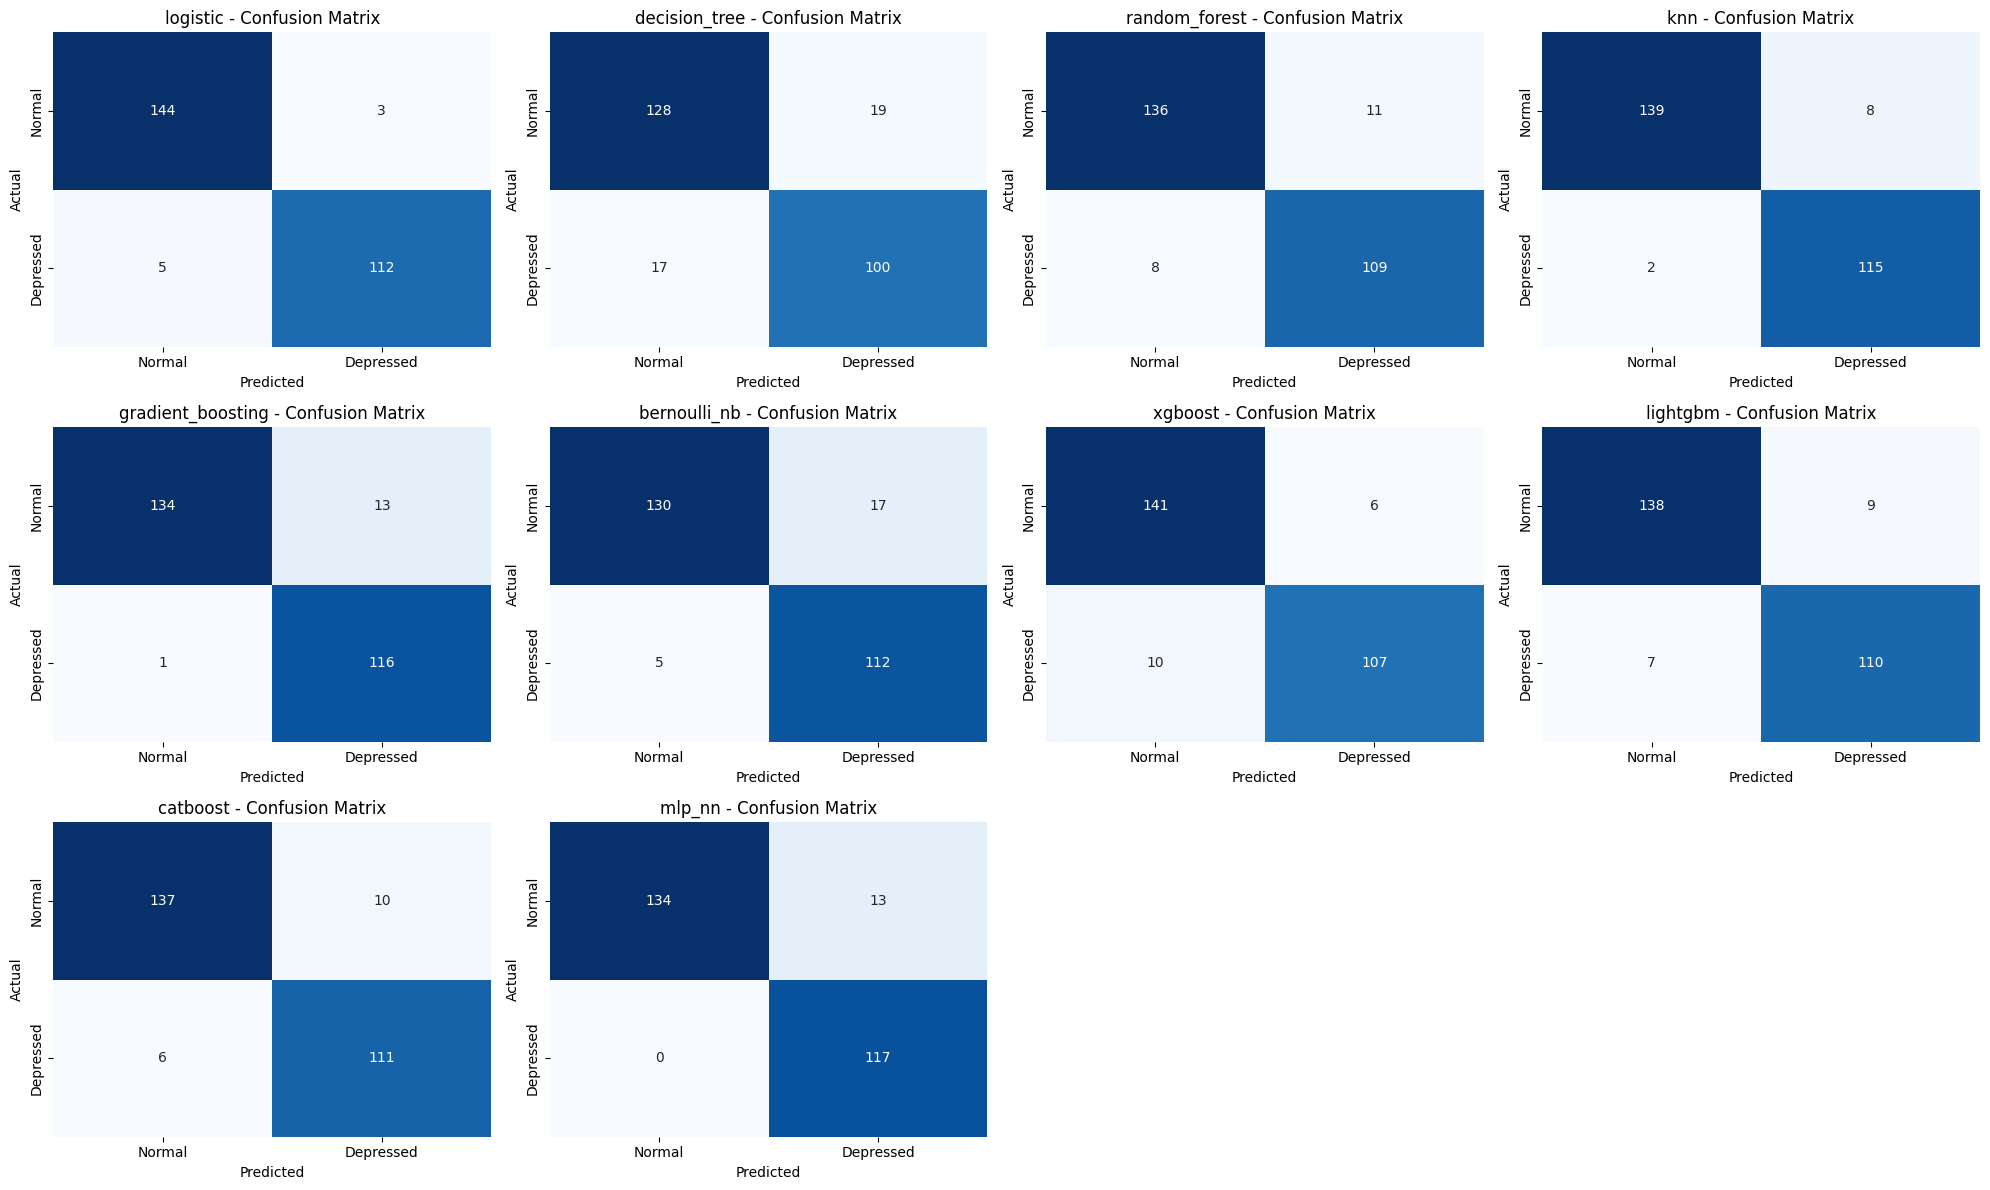

In [165]:
# Number of models
n_models = len(metrics_cv_all)
# Set up grid: 2 rows x N/2 columns (adjust if many models)
n_cols = 4  # adjust depending on how many models you want per row
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Flatten axes for easy indexing
axes = axes.flatten()

for i, (name, res) in enumerate(metrics_cv_all.items()):
    # Check if the confusion_matrix key exists for the current model
    if "confusion_matrix" in res:
        cm = res["confusion_matrix"]

        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Depressed"],
            yticklabels=["Normal", "Depressed"],
            ax=axes[i], cbar=False
        )
        axes[i].set_title(f"{name} - Confusion Matrix")
        axes[i].set_xlabel("Predicted")
        axes[i].set_ylabel("Actual")
    else:
        print(f"Skipping confusion matrix for {name}: 'confusion_matrix' not found in results.")
        # Hide this subplot if no data to plot
        fig.delaxes(axes[i])


# Hide any unused subplots
for j in range(i + 1 if 'i' in locals() else 0, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [166]:
# 1. Define a list named metrics_for_heatmap
metrics_for_heatmap = [
    'AUC OOF',
    'Balanced Accuracy',
    'Sensitivity (Recall)',
    'Specificity',
    'F1-Score',
    'Brier Score'
]

# 2. Create a new DataFrame called heatmap_data
# Ensure model_performance_df_sorted is available from previous steps
if 'model_performance_df_sorted' in locals():
    heatmap_data = model_performance_df_sorted.set_index('Model')[metrics_for_heatmap].copy()

    # 3. Drop any columns from heatmap_data that contain only NaN values
    # This ensures that if a metric was not calculated for any model, its column is removed
    heatmap_data = heatmap_data.dropna(axis=1, how='all')

    print("Prepared DataFrame for heatmap visualization:")
    print(heatmap_data.head())
else:
    print("Error: 'model_performance_df_sorted' DataFrame not found. Please ensure previous steps were executed.")

Prepared DataFrame for heatmap visualization:
                   AUC OOF  Balanced Accuracy  Sensitivity (Recall)  \
Model                                                                 
logistic            0.9950             0.9616                0.9573   
gradient_boosting   0.9852             0.9480                0.9573   
xgboost             0.9827             0.9351                0.8974   
catboost            0.9819             0.9387                0.9658   
lightgbm            0.9816             0.9327                0.9402   

                   Specificity  F1-Score  Brier Score  
Model                                                  
logistic                0.9660    0.9573       0.0309  
gradient_boosting       0.9388    0.9412       0.0464  
xgboost                 0.9728    0.9292       0.0534  
catboost                0.9116    0.9300       0.0532  
lightgbm                0.9252    0.9244       0.0595  


metrics_cv_all_models.json loaded successfully.
Prepared DataFrame for heatmap visualization:
                   AUC OOF  Balanced Accuracy  Sensitivity (Recall)  \
Model                                                                 
logistic            0.9961             0.9684                0.9573   
knn                 0.9948             0.9642                0.9829   
gradient_boosting   0.9867             0.9515                0.9915   
xgboost             0.9844             0.9369                0.9145   
mlp_nn              0.9834             0.9558                1.0000   

                   Specificity  F1-Score  Brier Score  
Model                                                  
logistic                0.9796    0.9655       0.0290  
knn                     0.9456    0.9583       0.0464  
gradient_boosting       0.9116    0.9431       0.0489  
xgboost                 0.9592    0.9304       0.0496  
mlp_nn                  0.9116    0.9474       0.1104  


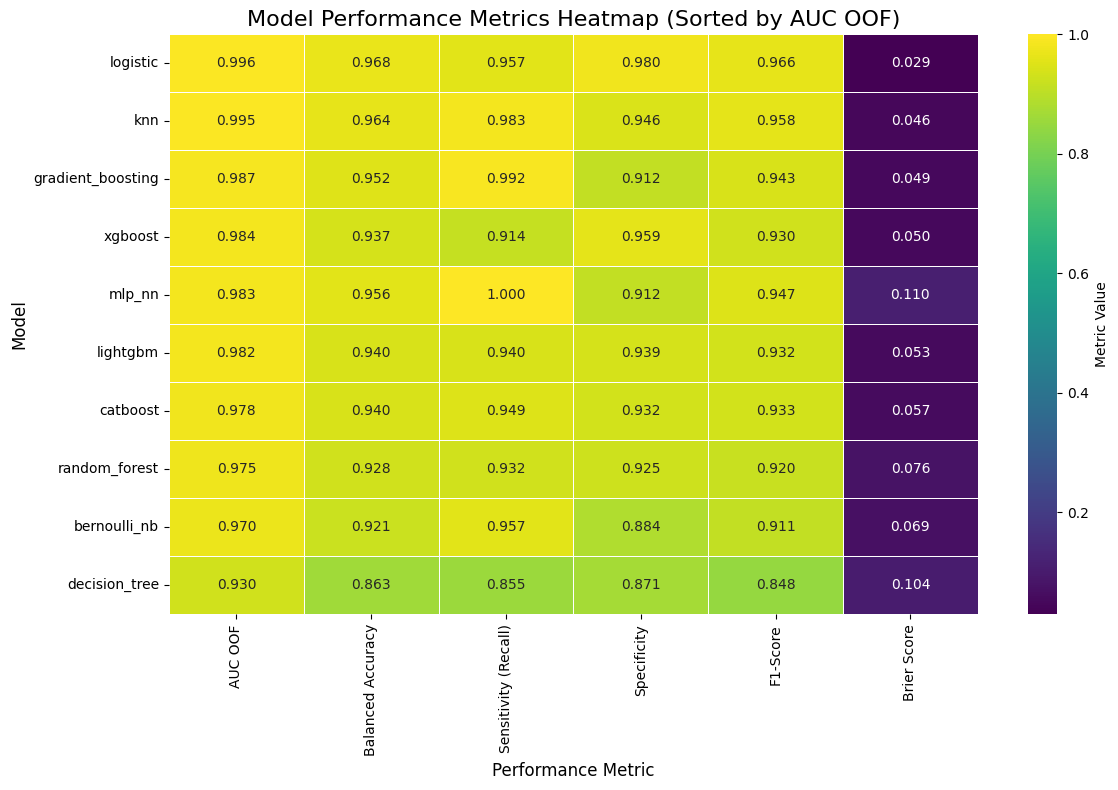

Model performance heatmap saved to outputs/model_performance_heatmap.png


In [167]:
# --- Step 1: Load metrics_cv_all ---
try:
    with open("outputs/metrics_cv_all_models.json", "r") as f:
        metrics_cv_all = json.load(f)
    print("metrics_cv_all_models.json loaded successfully.")
except FileNotFoundError:
    print("Error: 'outputs/metrics_cv_all_models.json' not found. Please ensure model evaluation steps were executed.")
    metrics_cv_all = {}

# --- Step 2: Create model_performance_df ---
model_performance_data = []
for model_name, metrics in metrics_cv_all.items():
    if "auc_oof" in metrics:
        model_performance_data.append({
            'Model': model_name,
            'AUC OOF': metrics.get('auc_oof'),
            'Balanced Accuracy': metrics.get('balanced_accuracy'),
            'Sensitivity (Recall)': metrics.get('sensitivity_recall'),
            'Specificity': metrics.get('specificity'),
            'F1-Score': metrics.get('f1'),
            'Brier Score': metrics.get('brier_score')
        })
model_performance_df = pd.DataFrame(model_performance_data)

# --- Step 3: Create model_performance_df_sorted ---
model_performance_df_sorted = model_performance_df.sort_values(by='AUC OOF', ascending=False).reset_index(drop=True)

# --- Step 4: Define metrics_for_heatmap and create heatmap_data ---
metrics_for_heatmap = [
    'AUC OOF',
    'Balanced Accuracy',
    'Sensitivity (Recall)',
    'Specificity',
    'F1-Score',
    'Brier Score'
]

if not model_performance_df_sorted.empty:
    heatmap_data = model_performance_df_sorted.set_index('Model')[metrics_for_heatmap].copy()
    heatmap_data = heatmap_data.dropna(axis=1, how='all')
    print("Prepared DataFrame for heatmap visualization:")
    print(heatmap_data.head())
else:
    print("Error: 'model_performance_df_sorted' DataFrame is empty. Cannot create heatmap_data.")

# --- Step 5: Generate and display the heatmap ---
os.makedirs("outputs", exist_ok=True)

if 'heatmap_data' in locals() and not heatmap_data.empty:
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        linewidths=.5,
        cbar_kws={'label': 'Metric Value'}
    )
    plt.title('Model Performance Metrics Heatmap (Sorted by AUC OOF)', fontsize=16)
    plt.xlabel('Performance Metric', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.tight_layout()

    heatmap_path = os.path.join("outputs", "model_performance_heatmap.png")
    plt.savefig(heatmap_path, dpi=300)
    plt.show()
    print(f"Model performance heatmap saved to {heatmap_path}")
else:
    print("No data available to generate heatmap.")

Combined ROC curves plot saved to outputs/combined_roc_curves.png


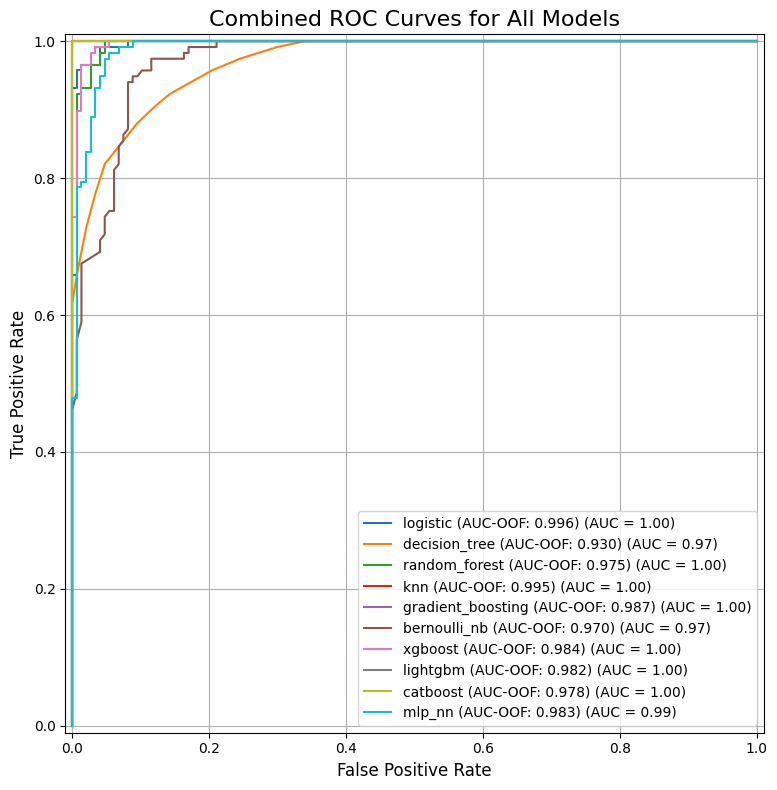

In [168]:
# 1. Create a new matplotlib figure and an axes object
fig, ax = plt.subplots(figsize=(10, 8))

# Load metrics_cv_all again for robustness in this cell's execution context
import json # Ensure json is imported
try:
    with open("outputs/metrics_cv_all_models.json", "r") as f:
        metrics_cv_all_loaded = json.load(f)
except FileNotFoundError:
    print("Error: 'outputs/metrics_cv_all_models.json' not found. Please run model evaluation cell first.")
    metrics_cv_all_loaded = {}


# 2. Iterate through each model in the models dictionary
for model_name, _ in models.items(): # models dictionary is available from previous cells
    try:
        # a. Construct the file path to its saved cross-validated pipeline
        model_path = f"outputs/{model_name}_cv.pkl"

        # b. Load the pipeline
        loaded_model = joblib.load(model_path)

        # c. Use the _predict_proba_safe function to get the predicted probabilities for the full dataset X
        predicted_probabilities = _predict_proba_safe(loaded_model, X) # X is available from previous cells

        # Retrieve and format auc_oof for the legend
        auc_oof = metrics_cv_all_loaded.get(model_name, {}).get('auc_oof')
        if auc_oof is not None:
            legend_label = f"{model_name} (AUC-OOF: {auc_oof:.3f})"
        else:
            legend_label = model_name # Fallback if auc_oof is not found

        # d. Plot the ROC curve on the same axes
        RocCurveDisplay.from_predictions(
            y, # y is available from previous cells
            predicted_probabilities,
            name=legend_label,  # Modified name parameter
            ax=ax
        )
    except FileNotFoundError:
        print(f"Warning: Model file not found for {model_name} at {model_path}. Skipping ROC plot for this model.")
    except Exception as e:
        print(f"Error plotting ROC for {model_name}: {e}")

# 3. Add a title to the plot
ax.set_title('Combined ROC Curves for All Models', fontsize=16)

# 4. Add a legend to distinguish between the ROC curves of different models
ax.legend(loc='lower right')

# Add labels and grid
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.grid(True)

# 5. Adjust the layout to prevent labels from overlapping and save the plot
plt.tight_layout()
plot_path = "outputs/combined_roc_curves.png"
plt.savefig(plot_path, dpi=300)
print(f"Combined ROC curves plot saved to {plot_path}")

# 6. Display the plot
plt.show()

In [169]:
logistic_risk_scores = pd.read_csv("/content/outputs/full_risk_scores_logistic.csv")

risk_action_map = {
    "very_low": "Routine care",
    "mild": "Psychoeducation",
    "moderate": "Psychosocial support",
    "high": "Refer + mhGAP interventions",
    "very_high": "Urgent referral / safety plan",
}

logistic_risk_scores["clinical_action"] = logistic_risk_scores["risk_band_logistic"].map(risk_action_map)

print("Loaded logistic_risk_scores DataFrame:")
print(logistic_risk_scores.head())
print("Logistic Risk Scores with Clinical Actions:")
print(logistic_risk_scores.head())

Loaded logistic_risk_scores DataFrame:
   binary_depr  risk_logistic risk_band_logistic  \
0            0       0.023825           very_low   
1            1       0.999343          very_high   
2            0       0.008108           very_low   
3            0       0.000011           very_low   
4            1       0.752536               high   

                 clinical_action  
0                   Routine care  
1  Urgent referral / safety plan  
2                   Routine care  
3                   Routine care  
4    Refer + mhGAP interventions  
Logistic Risk Scores with Clinical Actions:
   binary_depr  risk_logistic risk_band_logistic  \
0            0       0.023825           very_low   
1            1       0.999343          very_high   
2            0       0.008108           very_low   
3            0       0.000011           very_low   
4            1       0.752536               high   

                 clinical_action  
0                   Routine care  
1  Urgent r

In [170]:
# 1. Retrieve the best model pipeline by loading the saved *fitted* model
# The evaluate_5fold_cv function saves the final fitted model as '{model_key}_cv.pkl'
best_model = joblib.load(f"outputs/{best_cv}_cv.pkl")

# 2. Access the 'prep' step of the best_model pipeline to get the fitted preprocessor
fitted_preprocessor = best_model.named_steps['prep']

# 3. Call the get_feature_names_out() method on the fitted preprocessor
feature_names_preprocessed = fitted_preprocessor.get_feature_names_out()

print(f"Best model identified: {best_cv}")
print(f"Number of preprocessed features: {len(feature_names_preprocessed)}")
print("First 10 preprocessed feature names:")
print(feature_names_preprocessed[:10])

Best model identified: logistic
Number of preprocessed features: 9
First 10 preprocessed feature names:
['num__Littleinterestorpleasureind_1' 'num__Feelingdowndepressedorhope_1'
 'num__Troublefallingorstayingaslee_1'
 'num__Feelingtiredorhavinglittlee_1' 'num__Poorappetiteorovereating_1'
 'num__Feelingbadaboutyourselfor_1' 'num__Troubleconcentratingonthings_1'
 'num__Movingorspeakingsoslowlytha_1' 'num__Thoughtsthatyouwouldbebette_1']


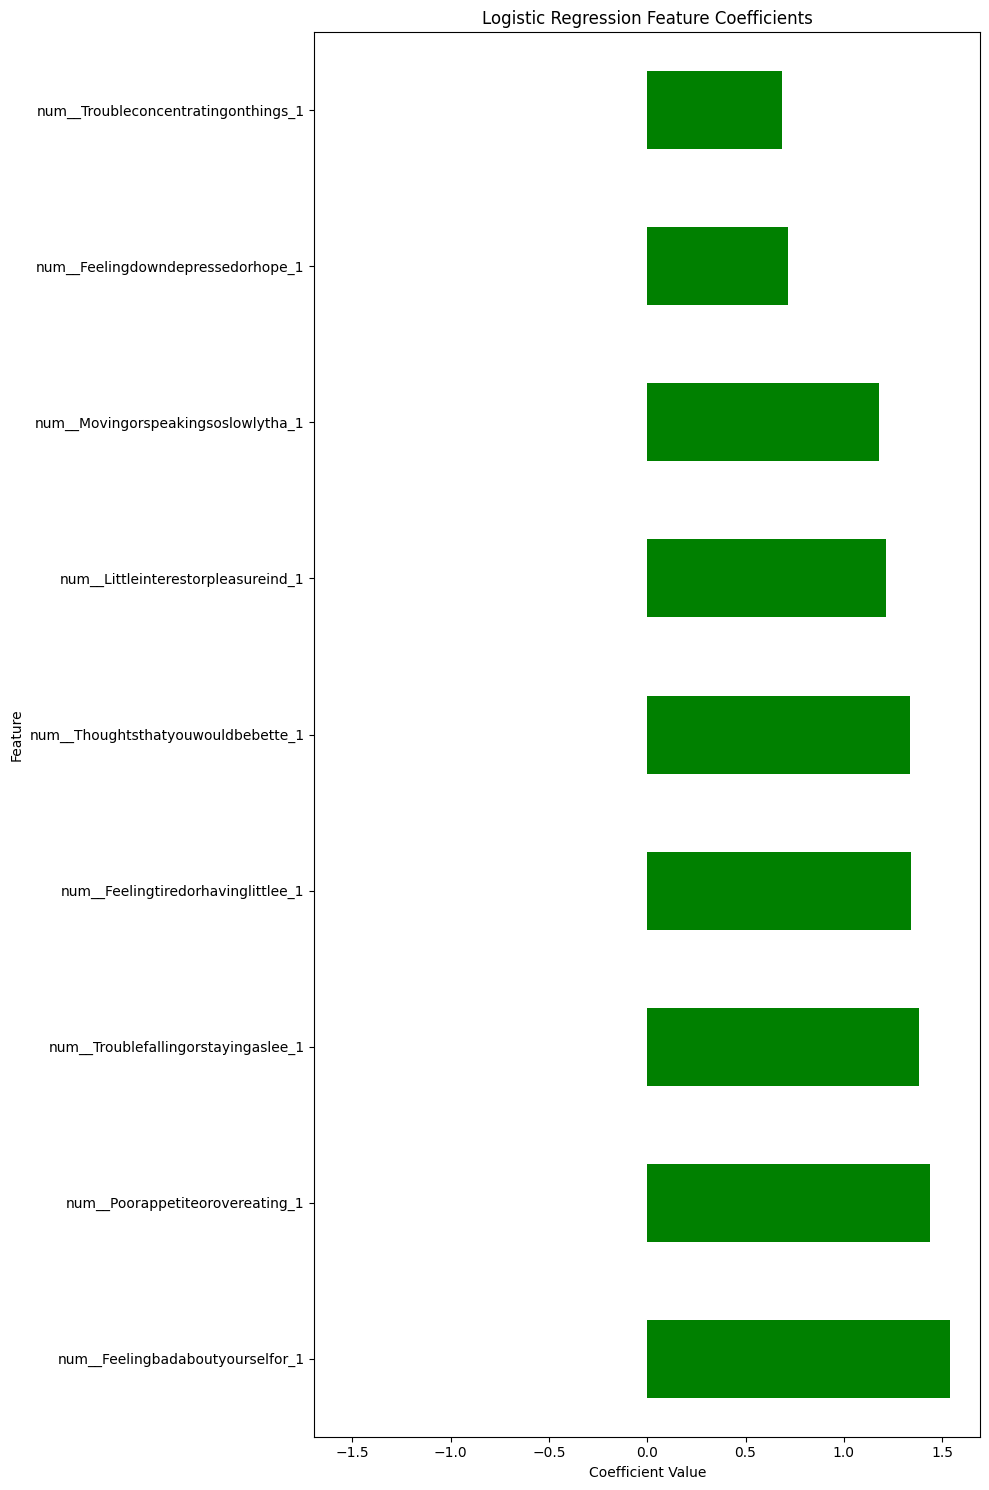

Logistic Regression Feature Coefficients plotted successfully.


In [171]:
# 1. Extract the LogisticRegression classifier
logistic_classifier = best_model.named_steps['clf']

# 2. Get the coefficients
# For binary classification, coef_ is a 2D array, so select the first row
coefficients = logistic_classifier.coef_[0]

# 3. Create a pandas Series
coef_df = pd.Series(coefficients, index=feature_names_preprocessed)

# 4. Sort coef_df by its values in descending order
coef_df = coef_df.sort_values(ascending=False)

# 5. Create a horizontal bar plot
plt.figure(figsize=(10, 15)) # Adjust figure size for better readability
coef_df.plot(kind='barh', color=['green' if x > 0 else 'red' for x in coef_df.values])

# 6. Set the title of the plot
plt.title('Logistic Regression Feature Coefficients')

# 7. Label the x-axis and y-axis
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')

# Adjust x-axis limits to clearly show positive and negative values
max_abs_coef = coef_df.abs().max()
plt.xlim(-max_abs_coef * 1.1, max_abs_coef * 1.1)

# 8. Adjust the layout and display the plot
plt.tight_layout()
plt.show()

print("Logistic Regression Feature Coefficients plotted successfully.")

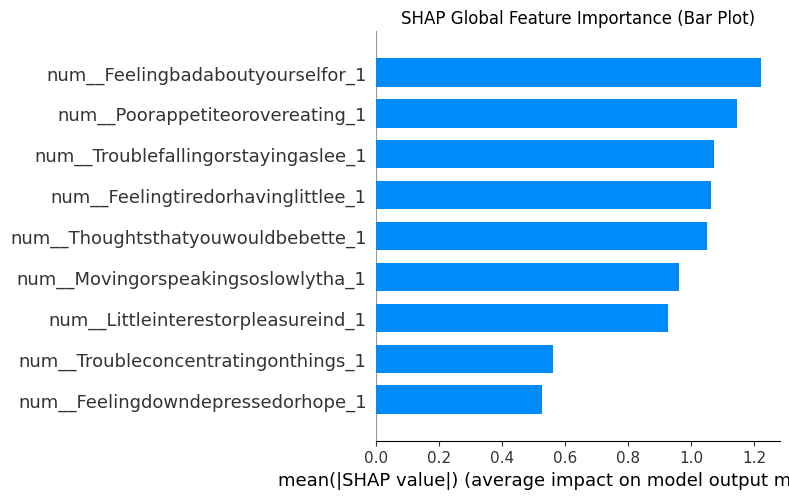

SHAP Global Feature Importance plot saved to outputs/shap_global_feature_importance.png


In [175]:
# Correct X_preprocessed for SHAP explainer
# Transform the full dataset X using the fitted_preprocessor
X_preprocessed = pd.DataFrame(
    fitted_preprocessor.transform(X),
    columns=feature_names_preprocessed
)

# Re-run the SHAP explainer and plot generation
import matplotlib.pyplot as plt

# 2. Extract the LogisticRegression classifier
logistic_classifier = best_model.named_steps['clf']

# 3. Create a shap.Explainer object
# For linear models like Logistic Regression, we can use LinearExplainer
# Given the model is Logistic Regression, LinearExplainer is appropriate and faster
explainer = shap.LinearExplainer(logistic_classifier, X_preprocessed)

# 4. Calculate the SHAP values
shap_values = explainer.shap_values(X_preprocessed)

# 5. Generate a SHAP summary plot of type 'bar' to visualize global feature importance
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
shap.summary_plot(shap_values, X_preprocessed, feature_names=feature_names_preprocessed, plot_type='bar', show=False)
plt.title('SHAP Global Feature Importance (Bar Plot)')
plt.tight_layout()

# 6. Save the generated SHAP summary plot
plot_path = "outputs/shap_global_feature_importance.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"SHAP Global Feature Importance plot saved to {plot_path}")

In [176]:
# Re-define _predict_proba_safe if not available in current scope
# (It was defined in XCcB_ZwxUH4c, assuming the notebook execution environment might reset state)
def _predict_proba_safe(pipe, X_data):
    """Return probability of class 1 for any classifier pipeline.
       Falls back to decision_function->sigmoid or to predicted labels."""
    if hasattr(pipe, "predict_proba"):
        return pipe.predict_proba(X_data)[:, 1]
    elif hasattr(pipe, "decision_function"):
        from scipy.special import expit
        return expit(pipe.decision_function(X_data))
    else:
        # final fallback: cast predictions to float in [0,1]
        y_hat = pipe.predict(X_data)
        # if predictions are {0,1}, this is fine; otherwise scale to [0,1]
        y_hat = (np.asarray(y_hat, dtype=float))
        if y_hat.max() > 1 or y_hat.min() < 0:
            # normalize to [0,1] if needed
            y_hat = (y_hat - y_hat.min()) / (y_hat.max() - y_hat.min() + 1e-9)
        return y_hat


# 1. Get predicted probabilities for the full dataset X
y_proba = _predict_proba_safe(best_model, X)

# 2. Determine the predicted labels using the best_threshold for the logistic model
# Load metrics_cv_all to get the best_threshold
with open("outputs/metrics_cv_all_models.json", "r") as f:
    metrics_cv_all = json.load(f)

best_threshold = metrics_cv_all['logistic']['best_threshold']
y_pred = (y_proba >= best_threshold).astype(int)

print("Predicted probabilities and labels computed.")

Predicted probabilities and labels computed.


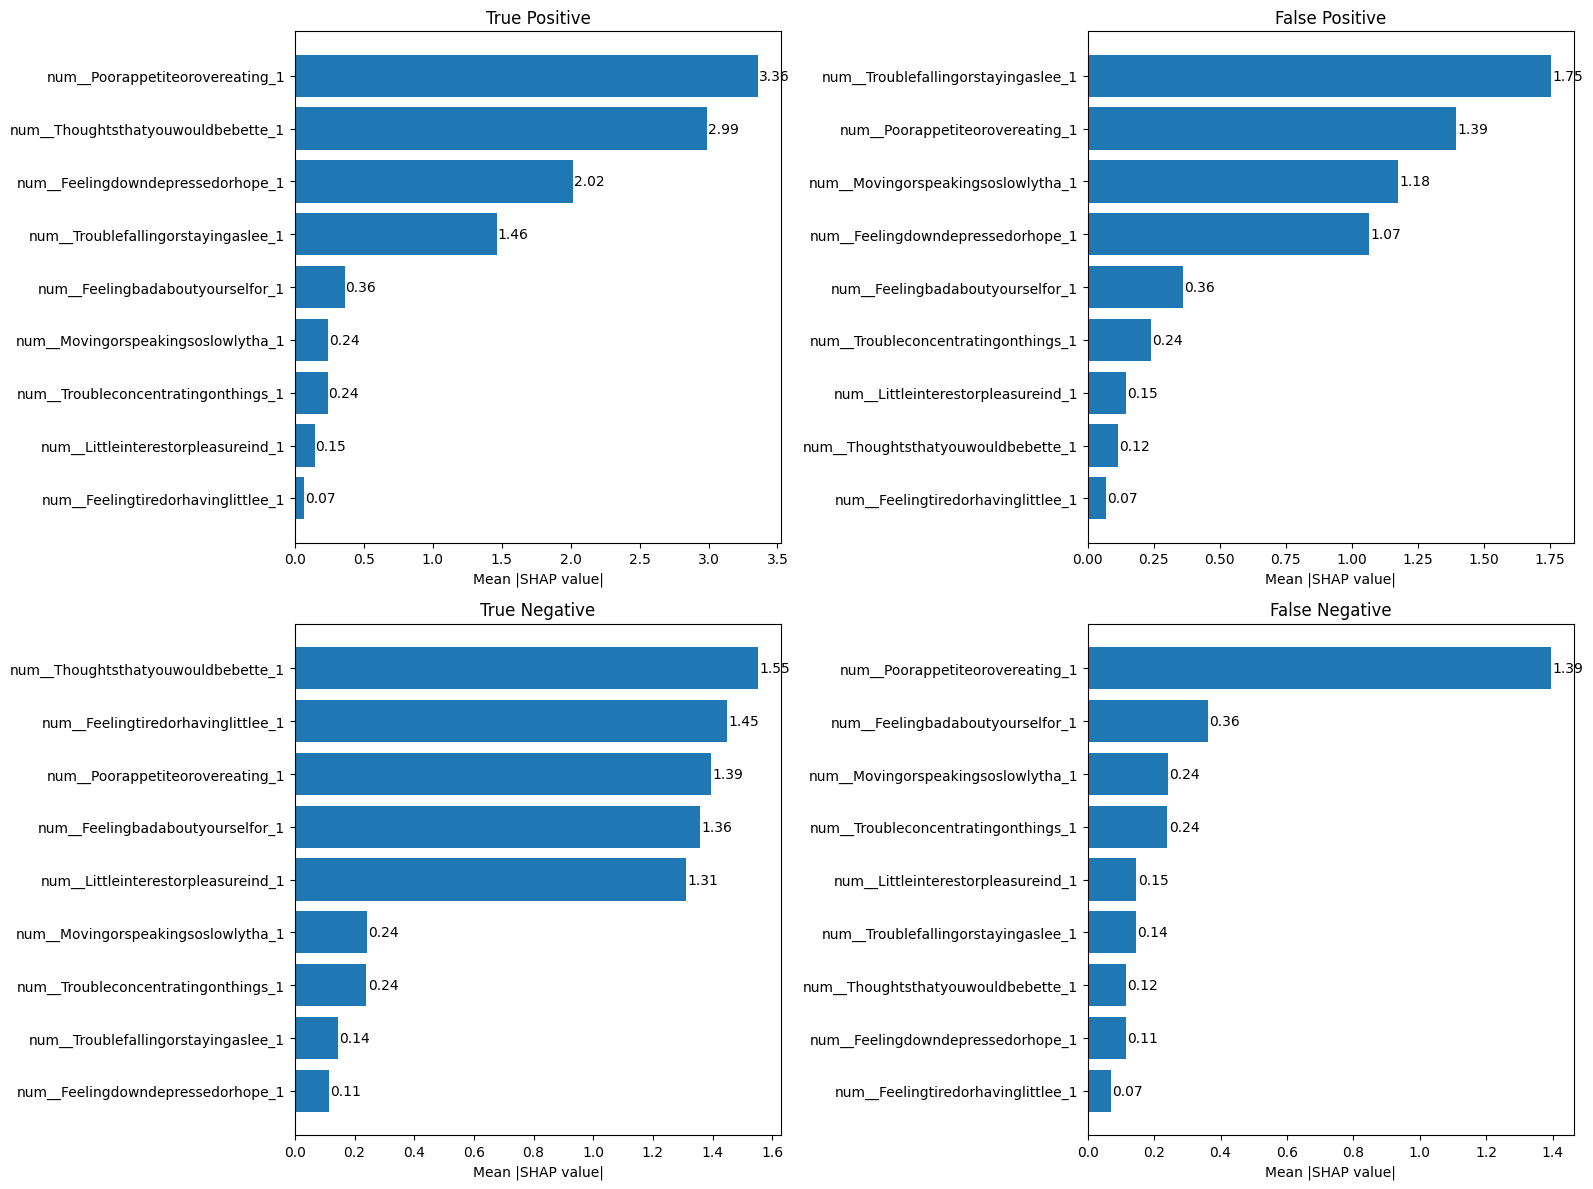

Saved top-10 SHAP feature matrix plot to outputs/shap_top_features_matrix.png


In [177]:
os.makedirs("outputs", exist_ok=True)

# Binary classifier output handling
classifier = best_model.named_steps['clf']

if isinstance(classifier, LogisticRegression):
    explainer = shap.LinearExplainer(classifier, X_preprocessed)
elif isinstance(classifier, (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier, LGBMClassifier, CatBoostClassifier)):
    explainer = shap.TreeExplainer(classifier, X_preprocessed)
else:
    print("Warning: Using KernelExplainer (slow).")
    background_data = shap.sample(X_preprocessed, 100)
    explainer = shap.KernelExplainer(classifier.predict_proba, background_data)

# Prepare instance indices
y_array = y.values if isinstance(y, pd.Series) else y
instance_types = {
    "True Positive": np.where((y_array == 1) & (y_pred == 1))[0][:1],
    "False Positive": np.where((y_array == 0) & (y_pred == 1))[0][:1],
    "True Negative": np.where((y_array == 0) & (y_pred == 0))[0][:1],
    "False Negative": np.where((y_array == 1) & (y_pred == 0))[0][:1],
}

# Initialize plot: 2 rows × 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (inst_type, idx_arr) in enumerate(instance_types.items()):
    if len(idx_arr) == 0:
        axes[i].text(0.5, 0.5, "No instance", ha="center", va="center", fontsize=14)
        axes[i].set_title(inst_type)
        axes[i].axis("off")
        continue

    idx = idx_arr[0]
    instance_data_df = X_preprocessed.iloc[[idx]]
    shap_values = explainer.shap_values(instance_data_df)

    # Get SHAP values for positive class (common for binary classification)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]

    shap_df = pd.Series(np.abs(shap_values[0]), index=feature_names_preprocessed)
    shap_df = shap_df.sort_values(ascending=False).head(10)  # top 10 features

    # Horizontal bar plot
    axes[i].barh(shap_df.index[::-1], shap_df.values[::-1])
    axes[i].set_xlabel("Mean |SHAP value|")
    axes[i].set_title(inst_type)

    # Annotate values to two decimal places
    for j, val in enumerate(shap_df.values[::-1]):
        axes[i].text(val + 0.005, j, f"{val:.2f}", va='center')

plt.tight_layout()
plt.savefig("outputs/shap_top_features_matrix.png", dpi=300)
plt.show()
plt.close(fig)

print("Saved top-10 SHAP feature matrix plot to outputs/shap_top_features_matrix.png")

In [178]:
import shap
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd

os.makedirs("outputs/shap_summary_top10", exist_ok=True)

for name, model in models.items():
    try:
        # Fit model on training data
        model.fit(X_train, y_train)

        # Initialize SHAP explainer dynamically
        classifier = model.named_steps['clf']
        if isinstance(classifier, (DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier, LGBMClassifier, CatBoostClassifier)):
            explainer = shap.TreeExplainer(classifier, X_train)
        elif isinstance(classifier, LogisticRegression):
            explainer = shap.LinearExplainer(classifier, X_train)
        else:
            print(f"Using KernelExplainer for {name}, may be slow.")
            background_data = shap.sample(X_train, 100)
            explainer = shap.KernelExplainer(classifier.predict_proba, background_data)

        # Compute SHAP values on test data
        shap_values = explainer.shap_values(X_test)
        if isinstance(shap_values, list):
            shap_vals_for_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
        else:
            shap_vals_for_plot = shap_values

        # Compute mean absolute SHAP values per feature
        mean_abs_shap = np.abs(shap_vals_for_plot).mean(axis=0)
        feature_importance = pd.Series(mean_abs_shap, index=X_test.columns)
        top_features = feature_importance.sort_values(ascending=False).head(10).index

        # Plot top 10 features only
        plt.figure(figsize=(12, 8))
        print(f"Generating SHAP summary plot (Top 10 features) for {name}...")
        shap.summary_plot(
            shap_vals_for_plot[:, [X_test.columns.get_loc(f) for f in top_features]],
            X_test[top_features],
            plot_type="dot",
            show=False
        )

        # Save plot
        filename = f"outputs/shap_summary_top10/shap_summary_top10_{name}.png"
        plt.tight_layout()
        plt.savefig(filename, dpi=300, bbox_inches="tight")
        plt.close()
        print(f"Saved SHAP top-10 summary plot for {name} to {filename}")

    except Exception as e:
        print(f"Could not produce SHAP summary for {name}: {e}")

Generating SHAP summary plot (Top 10 features) for logistic...
Saved SHAP top-10 summary plot for logistic to outputs/shap_summary_top10/shap_summary_top10_logistic.png
Could not produce SHAP summary for decision_tree: Data must be 1-dimensional, got ndarray of shape (9, 2) instead
Could not produce SHAP summary for random_forest: Data must be 1-dimensional, got ndarray of shape (9, 2) instead
Using KernelExplainer for knn, may be slow.


  0%|          | 0/53 [00:00<?, ?it/s]

Could not produce SHAP summary for knn: Data must be 1-dimensional, got ndarray of shape (9, 2) instead
Generating SHAP summary plot (Top 10 features) for gradient_boosting...
Saved SHAP top-10 summary plot for gradient_boosting to outputs/shap_summary_top10/shap_summary_top10_gradient_boosting.png
Using KernelExplainer for bernoulli_nb, may be slow.


  0%|          | 0/53 [00:00<?, ?it/s]

Could not produce SHAP summary for bernoulli_nb: Data must be 1-dimensional, got ndarray of shape (9, 2) instead
Generating SHAP summary plot (Top 10 features) for xgboost...
Saved SHAP top-10 summary plot for xgboost to outputs/shap_summary_top10/shap_summary_top10_xgboost.png
Generating SHAP summary plot (Top 10 features) for lightgbm...
Saved SHAP top-10 summary plot for lightgbm to outputs/shap_summary_top10/shap_summary_top10_lightgbm.png
Generating SHAP summary plot (Top 10 features) for catboost...
Saved SHAP top-10 summary plot for catboost to outputs/shap_summary_top10/shap_summary_top10_catboost.png
Using KernelExplainer for mlp_nn, may be slow.


  0%|          | 0/53 [00:00<?, ?it/s]

Could not produce SHAP summary for mlp_nn: Data must be 1-dimensional, got ndarray of shape (9, 2) instead


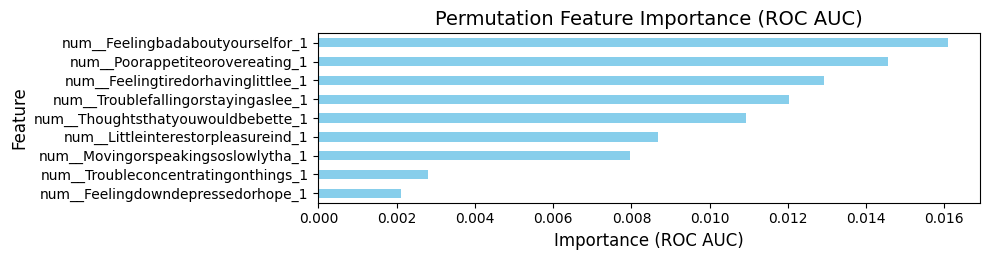

Permutation importance plot saved to outputs/permutation_importance_roc_auc.png


In [181]:
# 1. Calculate the permutation importance
# Use the original X DataFrame, as the best_model (pipeline) contains the preprocessor
perm_importance = permutation_importance(
    best_model,
    X, # Pass the original DataFrame X here
    y,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# 2. Create a pandas Series from the importances_mean attribute
# Use feature_names_preprocessed as the index for the results from the preprocessed model
perm_importance_df = pd.Series(perm_importance.importances_mean, index=feature_names_preprocessed)

# 3. Sort this Series by importance in descending order
perm_importance_df = perm_importance_df.sort_values(ascending=True) # Sort ascending for barh plot

# 4. Create a horizontal bar plot of the sorted permutation importances
plt.figure(figsize=(10, len(perm_importance_df) * 0.3))
perm_importance_df.plot(kind='barh', color='skyblue')

# 5. Add a title to the plot
plt.title('Permutation Feature Importance (ROC AUC)', fontsize=14)

# 6. Label the x-axis and y-axis
plt.xlabel('Importance (ROC AUC)', fontsize=12)
plt.ylabel('Feature', fontsize=12)

# Adjust layout for tight fit
plt.tight_layout()

# 7. Save the plot to the 'outputs' directory
plot_path = "outputs/permutation_importance_roc_auc.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Permutation importance plot saved to {plot_path}")


Generating 2x5 Matrix Plot for Top 10 Features...
Partial Dependence Plots matrix saved to outputs/pdp_matrix_plot_top_10.png


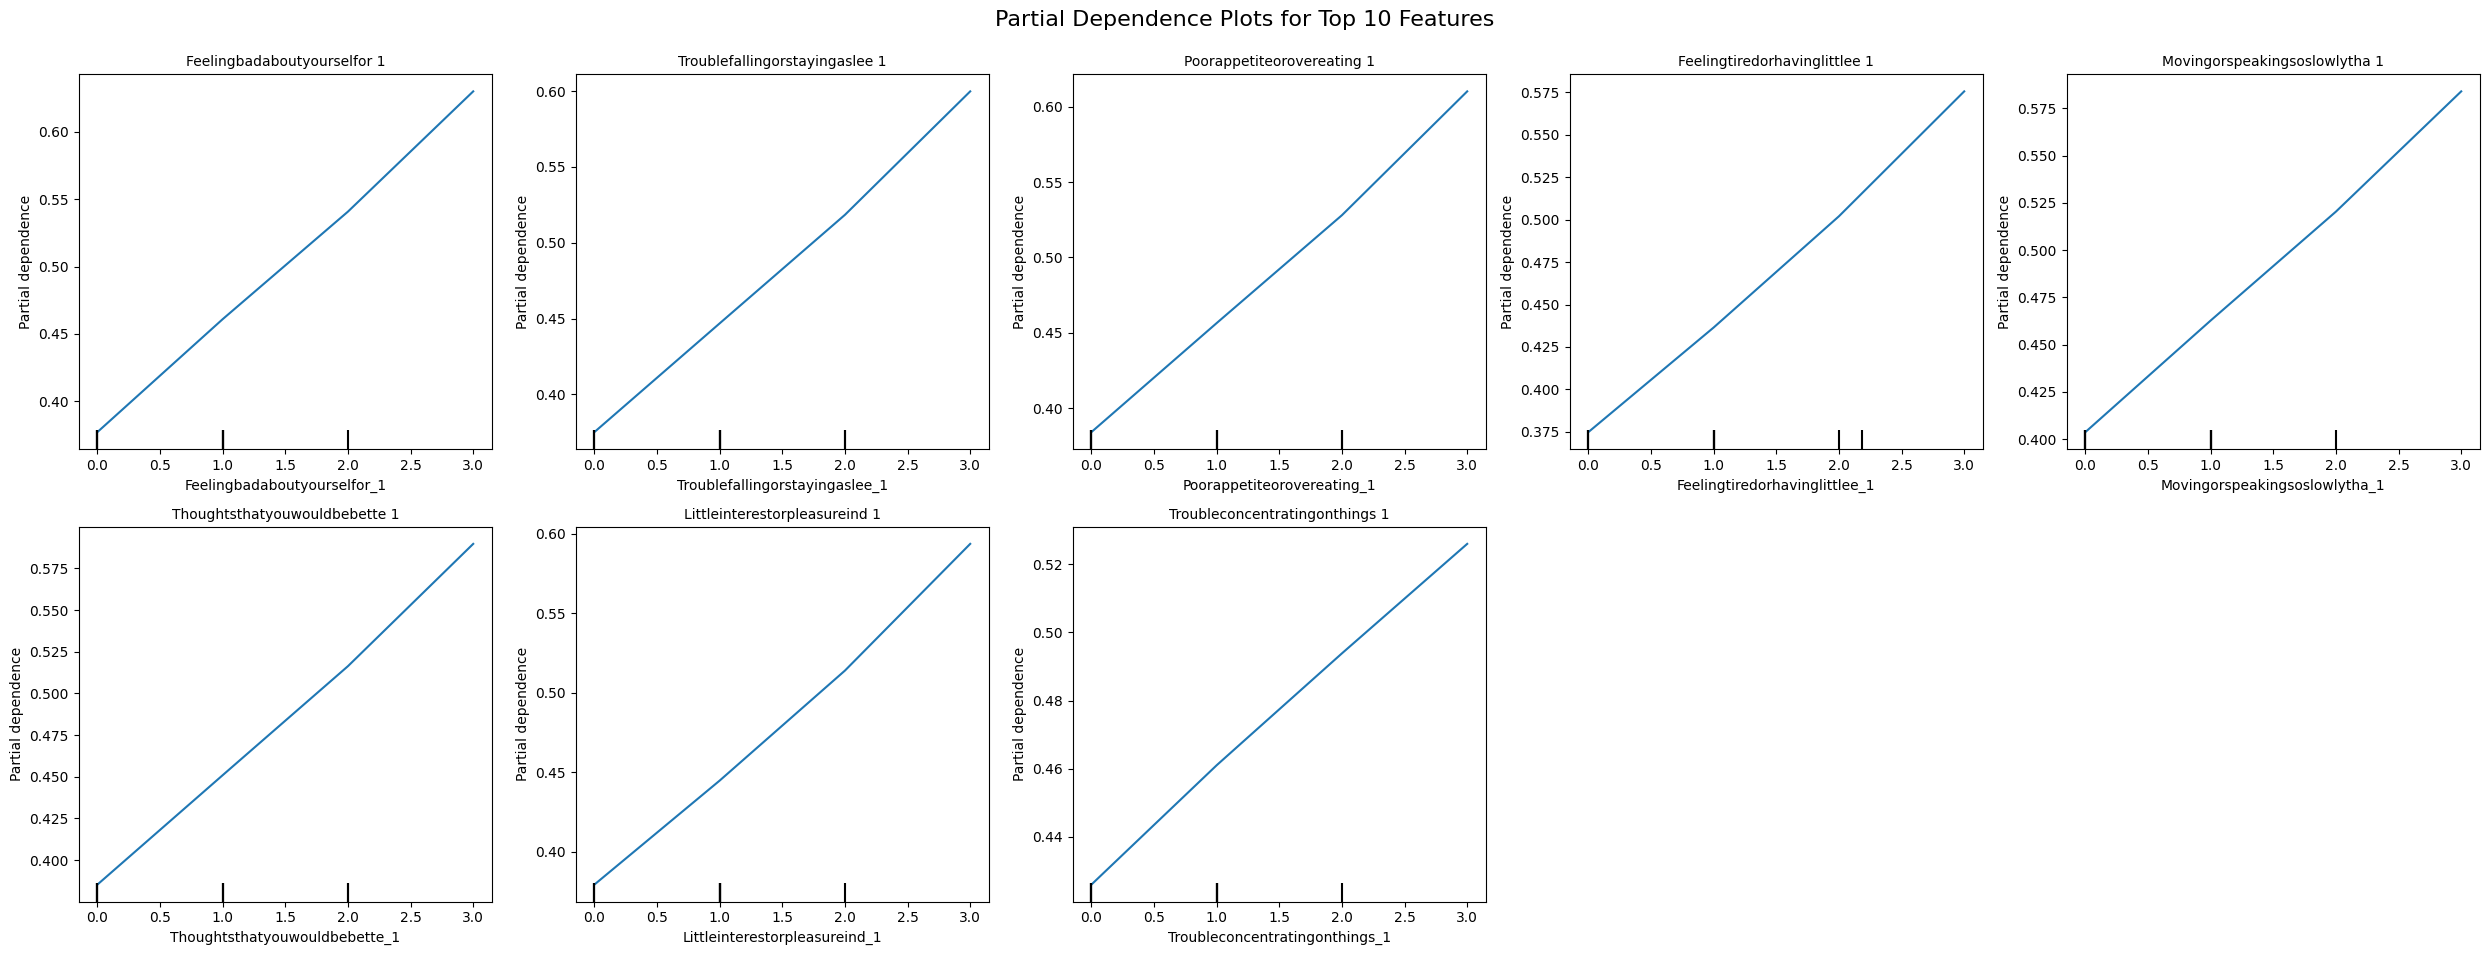

Finished generating 2x5 Matrix Plot for Top 10 Features.


In [180]:
# Ensure output directory exists
os.makedirs("outputs", exist_ok=True)

print("\nGenerating 2x5 Matrix Plot for Top 10 Features...")

# 1. Create a matplotlib figure with a 2x5 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

# 2. Iterate through top_10_features and the flattened axes array
for i, feature in enumerate(top_10_features):
    ax = axes[i]

    # a. Extract the original feature name by removing any 'num__' prefix
    original_feature_name = feature.replace('num__', '')

    # b. Determine whether to pass the original feature name (if it exists in X.columns)
    #    or its index in feature_names_preprocessed to the features argument of PartialDependenceDisplay.from_estimator.
    if original_feature_name in X.columns:
        pdp_features_to_plot = [original_feature_name]
        display_feature_name = original_feature_name
    else:
        try:
            # Find the index of the preprocessed feature name in the full list
            feature_idx = list(feature_names_preprocessed).index(feature)
            pdp_features_to_plot = [feature_idx]
            display_feature_name = feature # Use the preprocessed name for display
        except ValueError:
            print(f"Warning: Feature {feature} not found in preprocessed feature names. Skipping PDP.")
            ax.set_visible(False) # Hide the subplot if skipped
            continue

    try:
        display = PartialDependenceDisplay.from_estimator(
            estimator=best_model,        # The full pipeline
            X=X,                         # Original data (pipeline handles preprocessing)
            features=pdp_features_to_plot, # Feature(s) to plot PDP for
            feature_names=list(X.columns), # Names for original X columns for display if pdp_features are indices
            target=1,                    # Probability of class 1
            grid_resolution=20,          # Number of points to evaluate the PDP at
            ax=ax,
            kind='average'               # Use 'average' for standard PDP
        )

        # d. Set the title of the subplot to be descriptive of the feature.
        ax.set_title(f"{display_feature_name.replace('_', ' ').replace('num  ', '')}", fontsize=10)

        # e. Set the y-label for each subplot to 'Predicted Probability of Depression'
        #    and the x-label to the feature name.
        if i % 5 == 0: # Only set y-label for the first subplot in each row
            ax.set_ylabel('Predicted Probability of Depression', fontsize=9)
        else:
            ax.set_ylabel('') # Clear y-label for other subplots for cleaner look
        ax.set_xlabel(display_feature_name.replace('_', ' ').replace('num  ', ''), fontsize=9)

    except Exception as e:
        print(f"Error generating PDP for {feature}: {e}")
        ax.set_visible(False) # Hide the subplot on error

# Hide any unused subplots (if top_10_features has less than 10 items)
for j in range(len(top_10_features), len(axes)):
    axes[j].set_visible(False)

# 3. Use plt.tight_layout() to adjust subplot parameters for a tight layout.
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust rect to make space for suptitle
fig.suptitle('Partial Dependence Plots for Top 10 Features', fontsize=16)

# 4. Save the consolidated plot to the 'outputs' directory
plot_path = os.path.join("outputs", "pdp_matrix_plot_top_10.png")
plt.savefig(plot_path, dpi=300)
print(f"Partial Dependence Plots matrix saved to {plot_path}")

# 5. Display the plot
plt.show()
print("Finished generating 2x5 Matrix Plot for Top 10 Features.")

In [183]:
import pandas as pd

# 1. Calculate the absolute values of the coefficients
absolute_coef_df = coef_df.abs()

# 2. Sort these absolute coefficients in descending order and select the top 10
top_10_abs_coef = absolute_coef_df.nlargest(10)

# 3. Create a pandas DataFrame containing the top 10 feature names, their absolute coefficient values
#    and their original coefficient values to indicate the direction of influence
top_10_features_data = []
for feature_name, abs_value in top_10_abs_coef.items():
    original_value = coef_df[feature_name]
    top_10_features_data.append({
        'Feature': feature_name,
        'Absolute Importance': abs_value,
        'Direction of Influence': original_value
    })

top_10_importance_df = pd.DataFrame(top_10_features_data)

# 4. Rename the columns of this DataFrame to be descriptive
top_10_importance_df = top_10_importance_df.rename(columns={
    'Direction of Influence': 'Original Coefficient (Direction)'
})

# 5. Print the resulting DataFrame to display the top 10 feature importance table
print("\nTop 10 Feature Importance (Logistic Regression Coefficients):\n")
print(top_10_importance_df.to_string())



Top 10 Feature Importance (Logistic Regression Coefficients):

                               Feature  Absolute Importance  Original Coefficient (Direction)
0     num__Feelingbadaboutyourselfor_1             1.538727                          1.538727
1      num__Poorappetiteorovereating_1             1.439840                          1.439840
2  num__Troublefallingorstayingaslee_1             1.384508                          1.384508
3   num__Feelingtiredorhavinglittlee_1             1.339609                          1.339609
4   num__Thoughtsthatyouwouldbebette_1             1.335520                          1.335520
5   num__Littleinterestorpleasureind_1             1.215484                          1.215484
6   num__Movingorspeakingsoslowlytha_1             1.180342                          1.180342
7    num__Feelingdowndepressedorhope_1             0.714366                          0.714366
8  num__Troubleconcentratingonthings_1             0.684547                          0.684

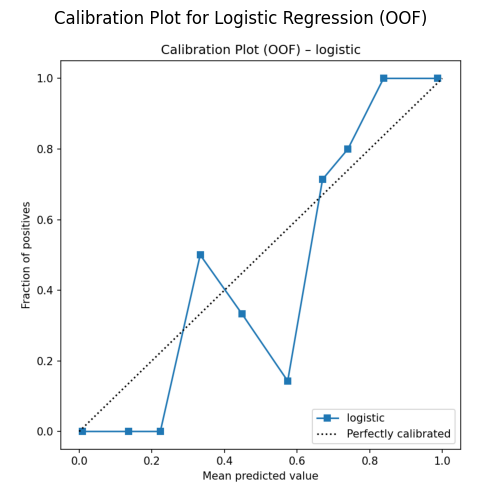

Displayed calibration plot from outputs/calibration_oof_logistic.png


In [184]:
# 1. Construct the file path to the calibration curve image for the 'logistic' model
image_path = os.path.join("outputs", "calibration_oof_logistic.png")

# 2. Load the image
img = plt.imread(image_path)

# 3. Display the image
plt.figure(figsize=(8, 6))
plt.imshow(img)

# 4. Add a descriptive title
plt.title('Calibration Plot for Logistic Regression (OOF)')

# 5. Remove axes ticks for cleaner display
plt.axis('off')

# 6. Show the plot
plt.show()

print(f"Displayed calibration plot from {image_path}")

In [185]:
import sys
!{sys.executable} -m pip install streamlit

In [192]:
%%writefile app.py
# ================================
# STREAMLIT AI DEPRESSION RISK TOOL
# For PLHIV using PHQ-9 + Clinical + Risk Factor data
# ================================

import streamlit as st
import pandas as pd
import numpy as np
import joblib

# --------------------------------------
# LOAD TRAINED MODEL
# --------------------------------------
@st.cache_resource
def load_model():
    # Use the best_cv variable to load the correct model file
    # The best_cv variable is available from previous cells and was determined to be 'logistic'
    # The evaluate_5fold_cv function saves the final fitted model as '{model_key}_cv.pkl'
    best_model_name = "logistic" # Assuming 'logistic' was determined as best_cv earlier
    model_path = f"outputs/{best_model_name}_cv.pkl"
    model = joblib.load(model_path)
    return model

model = load_model()

# --------------------------------------
# DECISION ENGINE (mhGAP-aligned)
# --------------------------------------
def decision_engine(risk):
    if risk < 0.20:
        action = "Very Low Risk: Reassure, routine care, monitor as needed."
    elif risk < 0.40:
        action = "Mild Risk: Provide psychoeducation, follow-up in 4 weeks."
    elif risk < 0.60:
        action = "Moderate Risk: Start mhGAP basic psychosocial support. Repeat PHQ-9 in 2 weeks."
    elif risk < 0.80:
        action = "High Risk: Initiate mhGAP interventions immediately. Consider referral if symptoms persist."
    else:
        action = "VERY HIGH RISK: URGENT referral required. Conduct safety assessment for self-harm."
    return action


# --------------------------------------
# STREAMLIT APP CONFIG
# --------------------------------------
st.set_page_config(
    page_title="AI Depression Screening Tool for PLHIV",
    layout="centered",
    initial_sidebar_state="expanded"
)

st.title("🧠 AI-Powered Depression Screening Tool for PLHIV")
st.markdown("""
This tool predicts **depression risk** among people living with HIV using an AI model built on
PHQ‑9 symptoms, HIV clinical indicators, and psychosocial risk factors.
""")


# ------------------------------------------------------------
# USER INPUTS — FORM
# ------------------------------------------------------------
st.header("📋 Enter Patient Information")

with st.form("input_form"):
    st.subheader("Demographics")
    age = st.number_input("Age", min_value=10, max_value=120, value=30)
    sex = st.selectbox("Sex", ["1", "2"])
    ethnicity = st.selectbox("Ethnicity", ["1", "2", "3", "4", "5", "6"])
    religion = st.selectbox("Religion", ["1", "2", "3", "4", "5", "6"])
    marital = st.selectbox("Marital Status", ["1", "2", "3", "4", "5"])
    education = st.selectbox("Education Level", ["1", "2", "3", "4"])
    occupation = st.selectbox("Occupation", ["1", "2", "3", "4", "5", "6", "7"])

    st.subheader("HIV Clinical Information")
    cd4 = st.number_input("CD4 Count", min_value=1, max_value=1500, value=450)
    art_duration = st.number_input("Months on ART", min_value=0, max_value=360, value=24)
    hiv_stage = st.selectbox("HIV Stage", ["1", "2", "3", "4"])
    tb_screen = st.selectbox("TB Screening Done?", ["1", "0"])
    tb_result = st.selectbox("TB Result (if done)", ["1", "0"])
    cough = st.selectbox("Cough >2 weeks", ["0", "1"])
    night_sweat = st.selectbox("Night sweats", ["0", "1"])
    fever = st.selectbox("Chills/Fever", ["0", "1"])
    chest_pain = st.selectbox("Chest Pain", ["0", "1"])
    weight_loss = st.selectbox("Weight Loss", ["0", "1"])

    st.subheader("PHQ-9 Depression Symptoms (0=Not at all, 3=Nearly every day)")
    phq_items = []
    item_labels = [
        "Little interest or pleasure in doing things",
        "Feeling down, depressed, or hopeless",
        "Trouble falling or staying asleep",
        "Feeling tired or having little energy",
        "Poor appetite or overeating",
        "Feeling bad about yourself",
        "Trouble concentrating on things",
        "Moving or speaking slowly / very restless",
        "Thoughts of self-harm"
    ]
    for q in item_labels:
        phq_items.append(st.selectbox(q, [0,1,2,3]))

    st.subheader("Psychosocial, Behavioral & Cultural Factors")
    worry = st.selectbox("Often worried/anxious?", ["1","2","3","4"])
    loneliness = st.selectbox("Feel lonely often?", ["1","2","3","4"])
    substance = st.selectbox("Substance use?", ["0","1"])
    tobacco = st.selectbox("Use tobacco?", ["0","1"])
    stigma = st.selectbox("Experienced stigma?", ["1","2","3","4"])
    cultural = st.selectbox("Cultural beliefs impact health-seeking?", ["1","2","3","4"])

    submit = st.form_submit_button("🔍 Predict Depression Risk")


# ------------------------------------------------------------
# PREDICT RISK
# ------------------------------------------------------------
if submit:

    # ------- Construct Input DataFrame -------
    input_dict = {
        "Age": age,
        "Sex": sex,
        "Ethnicity": ethnicity,
        "Religion": religion,
        "Marital status": marital,
        "Educational level": education,
        "Occupation": occupation,

        "WhatisyourCD4count_": cd4,
        "HowlonghaveyoubeenonART_": art_duration,
        "StageofHIVclassification_": hiv_stage,
        "Haveyoueverbeenscreenedorq_": tb_screen,
        "Whatwasyourresult_": tb_result,
        "Coughfortwo2ormoreweeks_": cough,
        "Nightsweats_": night_sweat,
        "Chillsandfever_": fever,
        "Chestpain_": chest_pain,
        "Weightloss_": weight_loss,

        # PHQ-9 items:
        "Littleinterestorpleasureind_1": phq_items[0],
        "Feelingdowndepressedorhope_1": phq_items[1],
        "Troublefallingorstayingaslee_1": phq_items[2],
        "Feelingtiredorhavinglittlee_1": phq_items[3],
        "Poorappetiteorovereating_1": phq_items[4],
        "Feelingbadaboutyourselfor_1": phq_items[5],
        "Troubleconcentratingonthings_1": phq_items[6],
        "Movingorspeakingsoslowlytha_1": phq_items[7],
        "Thoughtsthatyouwouldbebette_1": phq_items[8],

        # psychosocial:
        "Doyoutendtoworryorfeelanx_1": worry,
        "Howoftendoyoufeellowinene_1": loneliness,
        "Doyouengageinsubstanceabuse_": substance,
        "Doyouusetobacco_": tobacco,
        "Doyouthinkthereisastigma_1": stigma,
        "Doculturalbeliefsinfluenceyo_1": cultural
    }

    user_df = pd.DataFrame([input_dict])

    # ------- Predict probability -------
    prob = model.predict_proba(user_df)[0][1]
    risk_score = float(prob)

    # ------- Decision engine -------
    action = decision_engine(risk_score)

    # ------- Display results -------
    st.success(f"### 📎 Depression Risk Score: **{risk_score:.3f}**")

    if risk_score < 0.20:
        st.info("### 🟢 Risk Category: **Very Low**")
    elif risk_score < 0.40:
        st.info("### 🟡 Risk Category: **Mild**")
    elif risk_score < 0.60:
        st.warning("### 🟠 Risk Category: **Moderate**")
    elif risk_score < 0.80:
        st.warning("### 🔶 Risk Category: **High**")
    else:
        st.error("### 🔴 Risk Category: **Very High**")

    st.markdown(f"### 📌 Recommended Action:\n{action}")
    st.markdown("---")
    st.markdown("This tool provides decision support and should be used together with clinical judgment.")

Overwriting app.py


In [187]:
import subprocess

# Kill any previously running streamlit processes
!kill $(lsof -t -i:8501) > /dev/null 2>&1 || true

# Run the Streamlit application in the background
process = subprocess.Popen(['streamlit', 'run', 'app.py'])

print("Streamlit app is running. Access it via the public URL provided by ngrok or localtunnel.")
print("Look for an output like 'External URL: http://...ngrok.io' or 'your-url.loca.lt'")


Streamlit app is running. Access it via the public URL provided by ngrok or localtunnel.
Look for an output like 'External URL: http://...ngrok.io' or 'your-url.loca.lt'


In [188]:
import sys
!{sys.executable} -m pip install pyngrok

In [189]:
import getpass

# Input your ngrok authtoken. Get it from https://dashboard.ngrok.com/get-started/your-authtoken
print("Enter your ngrok authtoken:")
AUTH_TOKEN = getpass.getpass()
!ngrok authtoken $AUTH_TOKEN


Enter your ngrok authtoken:
··········
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [190]:
from pyngrok import ngrok

# IMPORTANT: Using the AUTH_TOKEN obtained from the previous step
# If you run this cell again after a kernel restart, you might need to re-enter your authtoken in the previous 'getpass' cell.

# Ensure AUTH_TOKEN is available from the previous getpass cell
if 'AUTH_TOKEN' not in locals():
    raise NameError("AUTH_TOKEN is not defined. Please run the 'Enter your ngrok authtoken' cell first.")

ngrok.set_auth_token(AUTH_TOKEN)

# Terminate any existing ngrok tunnels
ngrok.kill()

# Start a new ngrok tunnel to port 8501 (Streamlit's default port)
NGROK_TUNNEL = ngrok.connect(8501)
print(f"Streamlit App URL: {NGROK_TUNNEL.public_url}")

Streamlit App URL: https://subangular-anabelle-unhealthy.ngrok-free.dev
